# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [56]:
import numpy as np

# Insert your values
Name = "No Name" # Replace with your name
CID = 123446 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of No Name [CID: 123446]

Your challenge code is E


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

In [60]:
# Spare cell

# To predict whether a given material will form a glass or not.


## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [68]:
# Installation of libraries
!pip install matminer # Datasets and featurisation
!pip install xgboost # For the XGBoost model

In [58]:
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
#info = get_all_dataset_info("matbench_glass")
info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_glass
Description: Matbench v0.1 test dataset for predicting full bulk metallic glass formation ability from chemical formula. Retrieved from "Nonequilibrium Phase Diagrams of Ternary Amorphous Alloys,’ a volume of the Landolt– Börnstein collection. Deduplicated according to composition, ensuring no compositions were reported as both GFA and not GFA (i.e., all reports agreed on the classification designation). For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	gfa: Target variable. Glass forming ability: 1 means glass forming and corresponds to amorphous, 0 means non full glass forming.
Num Entries: 5680
Reference: Y. Kawazoe, T. Masumoto, A.-P. Tsai, J.-Z. Yu, T. Aihara Jr. (1997) Y. Kawazoe, J.-Z. Yu, A.-P. Tsai, T. Masumoto (ed.) SpringerMaterials
Nonequilibrium Phase Diagrams of Ternary Amorphous All

In [59]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_glass")

print(df)

      composition    gfa
0              Al  False
1        Al(NiB)2   True
2     Al10Co21B19   True
3     Al10Co23B17   True
4     Al10Co27B13   True
...           ...    ...
5675        ZrTi9  False
5676      ZrTiSi2   True
5677      ZrTiSi3   True
5678       ZrVCo8   True
5679       ZrVNi2   True

[5680 rows x 2 columns]


Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

In [63]:
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

# Initialize the featurizer
# Using the preset "magpie" which includes a good set of element properties
ep = ElementProperty.from_preset("magpie")

# Convert composition strings to pymatgen Composition objects
# Using a try-except block to handle potential parsing errors for individual compositions
def parse_composition(formula):
    try:
        return Composition(formula)
    except Exception:
        return None

df['composition_parsed'] = df['composition'].apply(parse_composition)

# Drop rows where composition parsing failed
df.dropna(subset=['composition_parsed'], inplace=True)

# Featurize the DataFrame using the parsed composition column.
# Added ignore_errors=True to handle compositions that matminer might not be able to parse even after initial parsing.
df_featurized = ep.featurize_dataframe(df, col_id="composition_parsed", ignore_errors=True)

# Display the first few rows of the featurized DataFrame
print(df_featurized.head())

# Check for any NaN values introduced during featurization and handle them if necessary
print(f"Number of NaN values after featurization: {df_featurized.isnull().sum().sum()}")

# Drop rows with NaN values if any (for simplicity, but consider imputation for larger datasets)
df_featurized.dropna(inplace=True)

# Define features (X) and target (y)
X = df_featurized.drop(columns=["composition", "gfa", "composition_parsed"])
y = df_featurized["gfa"]

print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of X:\n", X.head())
print("First 5 rows of y:\n", y.head())

ElementProperty:   0%|          | 0/5680 [00:00<?, ?it/s]

   composition    gfa composition_parsed  MagpieData minimum Number  \
0           Al  False               (Al)                       13.0   
1     Al(NiB)2   True        (Al, Ni, B)                        5.0   
2  Al10Co21B19   True        (Al, Co, B)                        5.0   
3  Al10Co23B17   True        (Al, Co, B)                        5.0   
4  Al10Co27B13   True        (Al, Co, B)                        5.0   

   MagpieData maximum Number  MagpieData range Number  MagpieData mean Number  \
0                       13.0                      0.0                   13.00   
1                       28.0                     23.0                   15.80   
2                       27.0                     22.0                   15.84   
3                       27.0                     22.0                   16.72   
4                       27.0                     22.0                   18.48   

   MagpieData avg_dev Number  MagpieData mode Number  \
0                     0.0000  

Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

In [64]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# Using a 80/20 split, stratify by y to maintain class distribution, and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=CID, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4544, 132)
X_test shape: (1136, 132)
y_train shape: (4544,)
y_test shape: (1136,)


## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

In [69]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Initialize an XGBClassifier model
# Using a random state for reproducibility
model = XGBClassifier(random_state=CID, use_label_encoder=False, eval_metric='logloss') # Suppress warning for `use_label_encoder` and set a default `eval_metric`

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1] # Probability of the positive class (True)

# Evaluate the model
print("Model Evaluation (XGBoost):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:54:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Evaluation (XGBoost):
Accuracy: 0.8900
ROC-AUC Score: 0.9520

Classification Report (XGBoost):
              precision    recall  f1-score   support

       False       0.82      0.79      0.81       329
        True       0.91      0.93      0.92       807

    accuracy                           0.89      1136
   macro avg       0.87      0.86      0.86      1136
weighted avg       0.89      0.89      0.89      1136



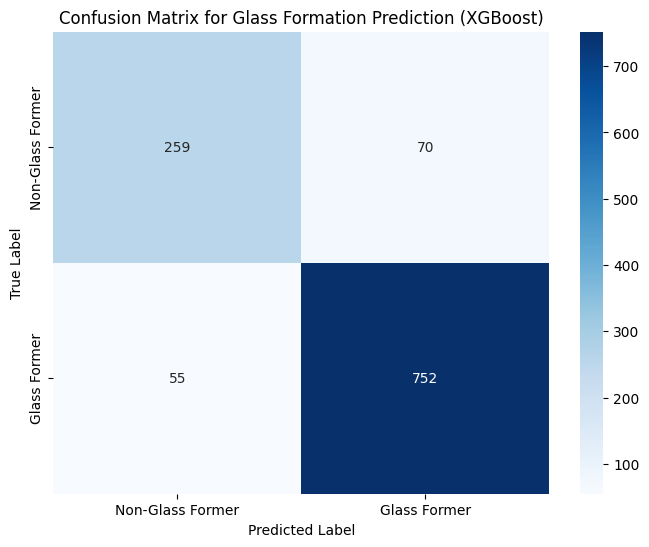

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels (False for non-glass, True for glass)
class_labels = ['Non-Glass Former', 'Glass Former']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Glass Formation Prediction (XGBoost)')
plt.show()

This confusion matrix helps visualize the model's performance:

*   **True Negatives (Top-Left):** The number of non-glass formers correctly identified as non-glass formers.
*   **False Positives (Top-Right):** The number of non-glass formers incorrectly identified as glass formers.
*   **False Negatives (Bottom-Left):** The number of glass formers incorrectly identified as non-glass formers.
*   **True Positives (Bottom-Right):** The number of glass formers correctly identified as glass formers.

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [66]:
# Spare cell for further model analysis

## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).